# Deep Learning Fundamentals - Mini-Project

## MNIST Digits - MLP Hyperparameters and Model Evaluation

### Imports and global state initialization

In [1]:
import torch
import lightning as L
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

from mnist_datamodule import MNISTDataModule
from mnist_mlp_classifier import MNISTMLP
from batch_size_evaluator import BatchSizeEvaluator
from hyperparameter_evaluator import HyperParameterEvaluator

In [2]:
if torch.cuda.is_available():
    torch.set_float32_matmul_precision("high")

/home/logus/env/iscte/mnist_digits/lib/python3.10/site-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


In [3]:
EPOCHS_SWEEP = 15
SEED = 42

### Initial baseline settings

In [4]:
baseline = dict(
    batch_size=256,
    lr=1e-3,
    optimizer="adamw",
    weight_decay=3e-4,
    activation="relu",
    width=512,
    depth=3,
    dropout_p=0.05,
    use_bn=True,
    weight_init="he",
)

In [5]:
# Helper function to cast a selected value to the same type as the baseline entry
def cast_like(v, like):
    v_py = v.item() if hasattr(v, "item") else v
    return type(like)(v_py)

### Define experimentation sweeps

In [6]:
# Sweep name, friendly title, candidate values
sweeps = [
    ("batch_size",   "Batch Size",               [64, 128, 256, 512, 1024]),
    ("width",        "Neurons per Hidden Layer", [64, 128, 256, 512, 1024]),
    ("depth",        "Hidden Layers (Depth)",    [1, 2, 3, 4, 5]),
    ("dropout_p",    "Dropout Probability",      [0.0, 0.1, 0.2, 0.5]),
    ("use_bn",       "BatchNorm",                [False, True]),
    ("lr",           "Learning Rate",            [5e-4, 8e-4, 1e-3, 2e-3]),
    ("weight_decay", "L2 Weight Decay",          [1e-4, 5e-4, 1e-3]),
    ("activation",   "Activation",               ["relu", "leakyrelu", "gelu", "elu", "tanh", "sigmoid"]),
    ("weight_init",  "Weight Initialization",    ["he", "xavier"]),
    ("optimizer",    "Optimizer",                ["adam", "adamw", "sgd", "rmsprop"]),
]

### Run experiment with batch size and all sweeps sequentially

Seed set to 42
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs



*** SWEEP: batch_size


***[RUN] batch_size=64 | seed=42
       hparams: width=512, depth=3, lr=0.001, dropout_p=0.05, use_bn=True, act=relu
       dataloader: batch_size=64, augment=True


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | encoder   | Sequential         | 930 K  | train
1 | head      | Linear             | 5.1 K  | train
2 | criterion | CrossEntropyLoss   | 0      | train
3 | acc_tr    | MulticlassAccuracy | 0      | train
4 | acc_va    | MulticlassAccuracy | 0      | train
5 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
935 K     Trainable params
0         Non-trainable params
935 K     Total params
3.742     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode


Epoch 14: 100%|██████████| 860/860 [00:06<00:00, 125.85it/s, v_num=26, train_loss_step=0.0234, val_loss=0.0463, val_acc=0.985, lr=0.001, train_loss_epoch=0.0852, train_acc=0.971] 

`Trainer.fit` stopped: `max_epochs=15` reached.


...


***[RESULT] batch_size=512 → best_val_acc=0.9878 (epoch 12), final_val_acc=0.9871 | best_val_loss=0.0378 (epoch 12), final_val_loss=0.0402


***[RUN] batch_size=1024 | seed=42
       hparams: width=512, depth=3, lr=0.001, dropout_p=0.05, use_bn=True, act=relu
       dataloader: batch_size=1024, augment=True


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | encoder   | Sequential         | 930 K  | train
1 | head      | Linear             | 5.1 K  | train
2 | criterion | CrossEntropyLoss   | 0      | train
3 | acc_tr    | MulticlassAccuracy | 0      | train
4 | acc_va    | MulticlassAccuracy | 0      | train
5 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
935 K     Trainable params
0         Non-trainable params
935 K     Total params
3.742     Total estimated model params size (MB)
18        Modules in train

Epoch 14: 100%|██████████| 54/54 [00:01<00:00, 31.57it/s, v_num=30, train_loss_step=0.0577, val_loss=0.0406, val_acc=0.987, lr=0.001, train_loss_epoch=0.0783, train_acc=0.973]

`Trainer.fit` stopped: `max_epochs=15` reached.


Epoch 14: 100%|██████████| 54/54 [00:01<00:00, 31.15it/s, v_num=30, train_loss_step=0.0577, val_loss=0.0406, val_acc=0.987, lr=0.001, train_loss_epoch=0.0783, train_acc=0.973]

***[RESULT] batch_size=1024 → best_val_acc=0.9861 (epoch 12), final_val_acc=0.9851 | best_val_loss=0.0406 (epoch 15), final_val_loss=0.0406
     param  value  best_val_acc  best_epoch  final_val_acc  best_val_loss  best_loss_epoch  final_val_loss
batch_size     64      0.988164          13       0.986181       0.038341               13        0.046316
batch_size    128      0.987925           9       0.986208       0.036055               15        0.036055
batch_size    512      0.987794          12       0.987064       0.037834               12        0.040211
batch_size    256      0.987692          11       0.987311       0.037068               14        0.037417
batch_size   1024      0.986087          12       0.985059       0.040642               15        0.040642


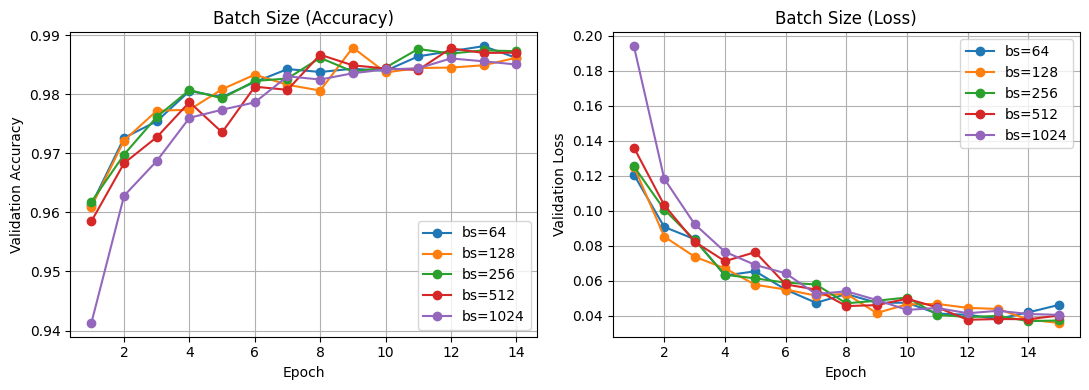

Seed set to 42
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


[selected] batch_size = 64

*** SWEEP: width

***[RUN] width=64 | seed=42
    hparams: activation=relu, depth=3, dropout_p=0.05, lr=0.001, optimizer=adamw, use_bn=True, weight_decay=0.0003, weight_init=he, width=64


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | encoder   | Sequential         | 58.9 K | train
1 | head      | Linear             | 650    | train
2 | criterion | CrossEntropyLoss   | 0      | train
3 | acc_tr    | MulticlassAccuracy | 0      | train
4 | acc_va    | MulticlassAccuracy | 0      | train
5 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
59.6 K    Trainable params
0         Non-trainable params
59.6 K    Total params
0.238     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode


Epoch 14: 100%|██████████| 860/860 [00:05<00:00, 153.09it/s, v_num=25, train_loss_step=0.489, val_loss=0.071, val_acc=0.979, lr=0.001, train_loss_epoch=0.208, train_acc=0.933]  

`Trainer.fit` stopped: `max_epochs=15` reached.


...

***[RESULT] width=512 → best_val_acc=0.9871 (epoch 13), final_val_acc=0.9832 | best_val_loss=0.0388 (epoch 13), final_val_loss=0.0393


***[RUN] width=1024 | seed=42
    hparams: activation=relu, depth=3, dropout_p=0.05, lr=0.001, optimizer=adamw, use_bn=True, weight_decay=0.0003, weight_init=he, width=1024


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | encoder   | Sequential         | 2.9 M  | train
1 | head      | Linear             | 10.2 K | train
2 | criterion | CrossEntropyLoss   | 0      | train
3 | acc_tr    | MulticlassAccuracy | 0      | train
4 | acc_va    | MulticlassAccuracy | 0      | train
5 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
2.9 M     Trainable params
0         Non-trainable params
2.9 M     Total params
11.678    Total estimated model params size (MB)
18        Modules in train

Epoch 14: 100%|██████████| 860/860 [00:05<00:00, 158.05it/s, v_num=29, train_loss_step=0.128, val_loss=0.0473, val_acc=0.986, lr=0.001, train_loss_epoch=0.0796, train_acc=0.973]  

`Trainer.fit` stopped: `max_epochs=15` reached.


Epoch 14: 100%|██████████| 860/860 [00:05<00:00, 156.64it/s, v_num=29, train_loss_step=0.128, val_loss=0.0473, val_acc=0.986, lr=0.001, train_loss_epoch=0.0796, train_acc=0.973]
***[RESULT] width=1024 → best_val_acc=0.9877 (epoch 13), final_val_acc=0.9849 | best_val_loss=0.0425 (epoch 14), final_val_loss=0.0473

param  value  best_val_acc  best_epoch  final_val_acc  best_val_loss  best_loss_epoch  final_val_loss
width    256      0.987861          13       0.986537       0.038578               13        0.040912
width   1024      0.987725          13       0.984928       0.042480               14        0.047262
width    512      0.987088          13       0.983165       0.038820               13        0.039340
width    128      0.983689          10       0.983416       0.050196               15        0.050196
width     64      0.978931          14       0.978931       0.068022               14        0.070995


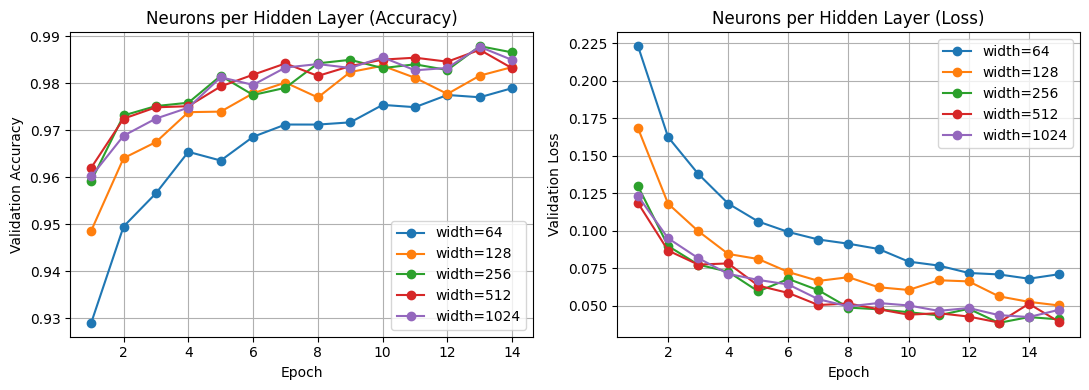

Seed set to 42
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


[selected] width = 256

*** SWEEP: depth

***[RUN] depth=1 | seed=42
    hparams: activation=relu, depth=1, dropout_p=0.05, lr=0.001, optimizer=adamw, use_bn=True, weight_decay=0.0003, weight_init=he, width=256


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | encoder   | Sequential         | 201 K  | train
1 | head      | Linear             | 2.6 K  | train
2 | criterion | CrossEntropyLoss   | 0      | train
3 | acc_tr    | MulticlassAccuracy | 0      | train
4 | acc_va    | MulticlassAccuracy | 0      | train
5 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
204 K     Trainable params
0         Non-trainable params
204 K     Total params
0.816     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode


Epoch 14: 100%|██████████| 860/860 [00:06<00:00, 130.51it/s, v_num=25, train_loss_step=0.249, val_loss=0.067, val_acc=0.979, lr=0.001, train_loss_epoch=0.135, train_acc=0.956]  

`Trainer.fit` stopped: `max_epochs=15` reached.


...

***[RESULT] depth=4 → best_val_acc=0.9848 (epoch 13), final_val_acc=0.9825 | best_val_loss=0.0449 (epoch 15), final_val_loss=0.0449


***[RUN] depth=5 | seed=42
    hparams: activation=relu, depth=5, dropout_p=0.05, lr=0.001, optimizer=adamw, use_bn=True, weight_decay=0.0003, weight_init=he, width=256


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | encoder   | Sequential         | 466 K  | train
1 | head      | Linear             | 2.6 K  | train
2 | criterion | CrossEntropyLoss   | 0      | train
3 | acc_tr    | MulticlassAccuracy | 0      | train
4 | acc_va    | MulticlassAccuracy | 0      | train
5 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
469 K     Trainable params
0         Non-trainable params
469 K     Total params
1.877     Total estimated model params size (MB)
26        Modules in train

Epoch 14: 100%|██████████| 860/860 [00:07<00:00, 112.01it/s, v_num=29, train_loss_step=0.171, val_loss=0.0493, val_acc=0.982, lr=0.001, train_loss_epoch=0.115, train_acc=0.962]  

`Trainer.fit` stopped: `max_epochs=15` reached.


Epoch 14: 100%|██████████| 860/860 [00:07<00:00, 111.77it/s, v_num=29, train_loss_step=0.171, val_loss=0.0493, val_acc=0.982, lr=0.001, train_loss_epoch=0.115, train_acc=0.962]
***[RESULT] depth=5 → best_val_acc=0.9845 (epoch 14), final_val_acc=0.9845 | best_val_loss=0.0446 (epoch 14), final_val_loss=0.0493

param  value  best_val_acc  best_epoch  final_val_acc  best_val_loss  best_loss_epoch  final_val_loss
depth      3      0.987861          13       0.986537       0.038578               13        0.040912
depth      2      0.986287          10       0.986066       0.042158               15        0.042158
depth      4      0.984833          13       0.982485       0.044861               15        0.044861
depth      5      0.984529          14       0.984529       0.044636               14        0.049336
depth      1      0.981500          14       0.981500       0.064428               14        0.067044


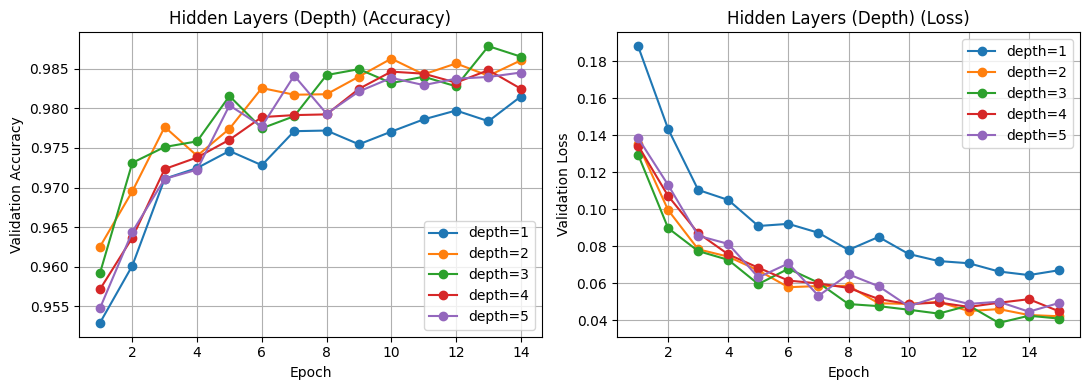

Seed set to 42
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


[selected] depth = 3

*** SWEEP: dropout_p

***[RUN] dropout_p=0.0 | seed=42
    hparams: activation=relu, depth=3, dropout_p=0.0, lr=0.001, optimizer=adamw, use_bn=True, weight_decay=0.0003, weight_init=he, width=256


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | encoder   | Sequential         | 334 K  | train
1 | head      | Linear             | 2.6 K  | train
2 | criterion | CrossEntropyLoss   | 0      | train
3 | acc_tr    | MulticlassAccuracy | 0      | train
4 | acc_va    | MulticlassAccuracy | 0      | train
5 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
336 K     Trainable params
0         Non-trainable params
336 K     Total params
1.347     Total estimated model params size (MB)
15        Modules in train mode
0         Modules in eval mode


Epoch 14: 100%|██████████| 860/860 [00:05<00:00, 158.20it/s, v_num=16, train_loss_step=0.00926, val_loss=0.0437, val_acc=0.985, lr=0.001, train_loss_epoch=0.0873, train_acc=0.972]

`Trainer.fit` stopped: `max_epochs=15` reached.


...

***[RESULT] dropout_p=0.2 → best_val_acc=0.9848 (epoch 11), final_val_acc=0.9829 | best_val_loss=0.0469 (epoch 15), final_val_loss=0.0469


***[RUN] dropout_p=0.5 | seed=42
    hparams: activation=relu, depth=3, dropout_p=0.5, lr=0.001, optimizer=adamw, use_bn=True, weight_decay=0.0003, weight_init=he, width=256


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | encoder   | Sequential         | 334 K  | train
1 | head      | Linear             | 2.6 K  | train
2 | criterion | CrossEntropyLoss   | 0      | train
3 | acc_tr    | MulticlassAccuracy | 0      | train
4 | acc_va    | MulticlassAccuracy | 0      | train
5 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
336 K     Trainable params
0         Non-trainable params
336 K     Total params
1.347     Total estimated model params size (MB)
18        Modules in train

Epoch 14: 100%|██████████| 860/860 [00:05<00:00, 155.63it/s, v_num=19, train_loss_step=0.417, val_loss=0.0809, val_acc=0.976, lr=0.001, train_loss_epoch=0.308, train_acc=0.903] 

`Trainer.fit` stopped: `max_epochs=15` reached.


Epoch 14: 100%|██████████| 860/860 [00:05<00:00, 155.30it/s, v_num=19, train_loss_step=0.417, val_loss=0.0809, val_acc=0.976, lr=0.001, train_loss_epoch=0.308, train_acc=0.903]
***[RESULT] dropout_p=0.5 → best_val_acc=0.9784 (epoch 13), final_val_acc=0.9781 | best_val_loss=0.0747 (epoch 14), final_val_loss=0.0809

    param  value  best_val_acc  best_epoch  final_val_acc  best_val_loss  best_loss_epoch  final_val_loss
dropout_p    0.0      0.986705          13       0.981726       0.043683               15        0.043683
dropout_p    0.1      0.986264          14       0.986264       0.043256               14        0.045725
dropout_p    0.2      0.984781          11       0.982851       0.046916               15        0.046916
dropout_p    0.5      0.978385          13       0.978133       0.074718               14        0.080865


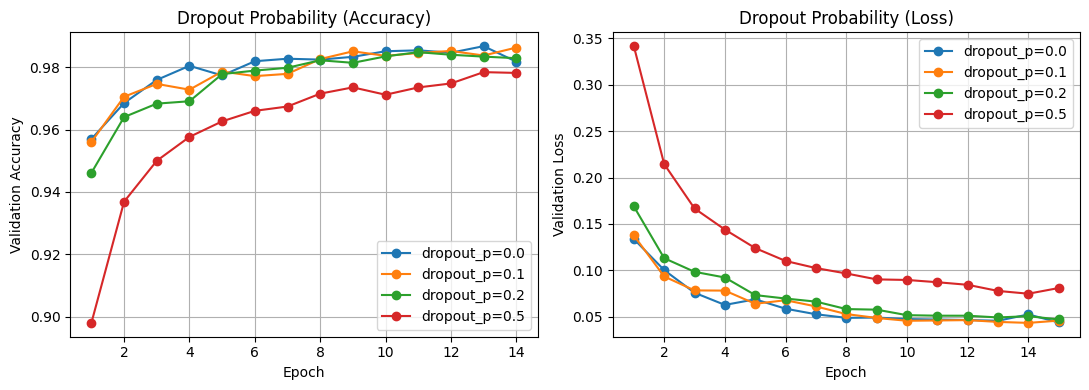

Seed set to 42
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


[selected] dropout_p = 0.0

*** SWEEP: use_bn

***[RUN] use_bn=False | seed=42
    hparams: activation=relu, depth=3, dropout_p=0.0, lr=0.001, optimizer=adamw, use_bn=False, weight_decay=0.0003, weight_init=he, width=256


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | encoder   | Sequential         | 332 K  | train
1 | head      | Linear             | 2.6 K  | train
2 | criterion | CrossEntropyLoss   | 0      | train
3 | acc_tr    | MulticlassAccuracy | 0      | train
4 | acc_va    | MulticlassAccuracy | 0      | train
5 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
335 K     Trainable params
0         Non-trainable params
335 K     Total params
1.340     Total estimated model params size (MB)
12        Modules in train mode
0         Modules in eval mode


Epoch 14: 100%|██████████| 860/860 [00:05<00:00, 155.38it/s, v_num=8, train_loss_step=0.0391, val_loss=0.0563, val_acc=0.983, lr=0.001, train_loss_epoch=0.0944, train_acc=0.970] 

`Trainer.fit` stopped: `max_epochs=15` reached.


...

***[RESULT] use_bn=False → best_val_acc=0.9832 (epoch 13), final_val_acc=0.9808 | best_val_loss=0.0563 (epoch 15), final_val_loss=0.0563


***[RUN] use_bn=True | seed=42
    hparams: activation=relu, depth=3, dropout_p=0.0, lr=0.001, optimizer=adamw, use_bn=True, weight_decay=0.0003, weight_init=he, width=256


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | encoder   | Sequential         | 334 K  | train
1 | head      | Linear             | 2.6 K  | train
2 | criterion | CrossEntropyLoss   | 0      | train
3 | acc_tr    | MulticlassAccuracy | 0      | train
4 | acc_va    | MulticlassAccuracy | 0      | train
5 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
336 K     Trainable params
0         Non-trainable params
336 K     Total params
1.347     Total estimated model params size (MB)
15        Modules in train

Epoch 14: 100%|██████████| 860/860 [00:05<00:00, 156.49it/s, v_num=9, train_loss_step=0.0851, val_loss=0.046, val_acc=0.985, lr=0.001, train_loss_epoch=0.0865, train_acc=0.971]  

`Trainer.fit` stopped: `max_epochs=15` reached.


Epoch 14: 100%|██████████| 860/860 [00:05<00:00, 156.15it/s, v_num=9, train_loss_step=0.0851, val_loss=0.046, val_acc=0.985, lr=0.001, train_loss_epoch=0.0865, train_acc=0.971]
***[RESULT] use_bn=True → best_val_acc=0.9851 (epoch 12), final_val_acc=0.9838 | best_val_loss=0.0421 (epoch 14), final_val_loss=0.0460

 param  value  best_val_acc  best_epoch  final_val_acc  best_val_loss  best_loss_epoch  final_val_loss
use_bn   True      0.985087          12       0.983794       0.042072               14        0.046034
use_bn  False      0.983195          13       0.980770       0.056325               15        0.056325


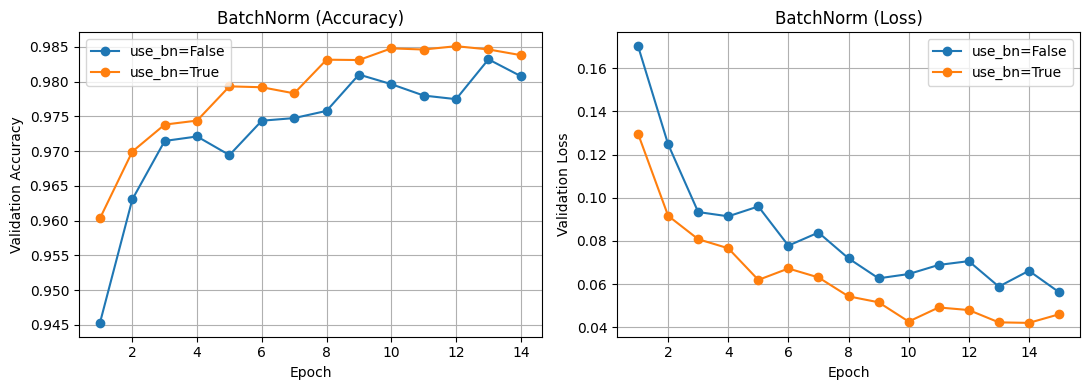

Seed set to 42
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


[selected] use_bn = True

*** SWEEP: lr

***[RUN] lr=0.0005 | seed=42
    hparams: activation=relu, depth=3, dropout_p=0.0, lr=0.0005, optimizer=adamw, use_bn=True, weight_decay=0.0003, weight_init=he, width=256


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | encoder   | Sequential         | 334 K  | train
1 | head      | Linear             | 2.6 K  | train
2 | criterion | CrossEntropyLoss   | 0      | train
3 | acc_tr    | MulticlassAccuracy | 0      | train
4 | acc_va    | MulticlassAccuracy | 0      | train
5 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
336 K     Trainable params
0         Non-trainable params
336 K     Total params
1.347     Total estimated model params size (MB)
15        Modules in train mode
0         Modules in eval mode


Epoch 14: 100%|██████████| 860/860 [00:05<00:00, 151.26it/s, v_num=16, train_loss_step=0.0361, val_loss=0.0472, val_acc=0.984, lr=0.0005, train_loss_epoch=0.0874, train_acc=0.970] 

`Trainer.fit` stopped: `max_epochs=15` reached.


...

***[RESULT] lr=0.001 → best_val_acc=0.9851 (epoch 12), final_val_acc=0.9838 | best_val_loss=0.0421 (epoch 14), final_val_loss=0.0460


***[RUN] lr=0.002 | seed=42
    hparams: activation=relu, depth=3, dropout_p=0.0, lr=0.002, optimizer=adamw, use_bn=True, weight_decay=0.0003, weight_init=he, width=256


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | encoder   | Sequential         | 334 K  | train
1 | head      | Linear             | 2.6 K  | train
2 | criterion | CrossEntropyLoss   | 0      | train
3 | acc_tr    | MulticlassAccuracy | 0      | train
4 | acc_va    | MulticlassAccuracy | 0      | train
5 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
336 K     Trainable params
0         Non-trainable params
336 K     Total params
1.347     Total estimated model params size (MB)
15        Modules in train

Epoch 14: 100%|██████████| 860/860 [00:05<00:00, 171.40it/s, v_num=19, train_loss_step=0.0936, val_loss=0.0435, val_acc=0.986, lr=0.002, train_loss_epoch=0.0881, train_acc=0.971] 

`Trainer.fit` stopped: `max_epochs=15` reached.


Epoch 14: 100%|██████████| 860/860 [00:05<00:00, 171.01it/s, v_num=19, train_loss_step=0.0936, val_loss=0.0435, val_acc=0.986, lr=0.002, train_loss_epoch=0.0881, train_acc=0.971]
***[RESULT] lr=0.002 → best_val_acc=0.9871 (epoch 13), final_val_acc=0.9868 | best_val_loss=0.0421 (epoch 13), final_val_loss=0.0435

param  value  best_val_acc  best_epoch  final_val_acc  best_val_loss  best_loss_epoch  final_val_loss
   lr 0.0020      0.987069          13       0.986800       0.042084               13        0.043526
   lr 0.0008      0.986026          14       0.986026       0.042751               14        0.043481
   lr 0.0005      0.985444          13       0.981431       0.047222               15        0.047222
   lr 0.0010      0.985087          12       0.983794       0.042072               14        0.046034


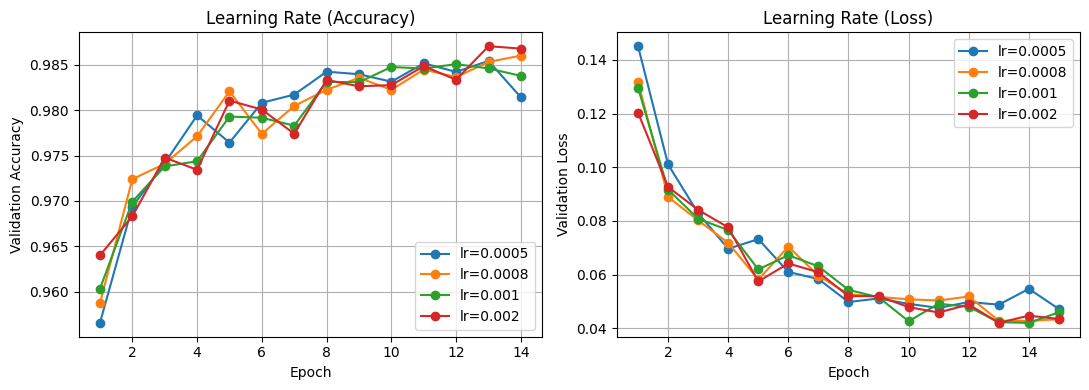

Seed set to 42
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


[selected] lr = 0.002

*** SWEEP: weight_decay

***[RUN] weight_decay=0.0001 | seed=42
    hparams: activation=relu, depth=3, dropout_p=0.0, lr=0.002, optimizer=adamw, use_bn=True, weight_decay=0.0001, weight_init=he, width=256


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | encoder   | Sequential         | 334 K  | train
1 | head      | Linear             | 2.6 K  | train
2 | criterion | CrossEntropyLoss   | 0      | train
3 | acc_tr    | MulticlassAccuracy | 0      | train
4 | acc_va    | MulticlassAccuracy | 0      | train
5 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
336 K     Trainable params
0         Non-trainable params
336 K     Total params
1.347     Total estimated model params size (MB)
15        Modules in train mode
0         Modules in eval mode


Epoch 14: 100%|██████████| 860/860 [00:05<00:00, 156.39it/s, v_num=12, train_loss_step=0.108, val_loss=0.034, val_acc=0.989, lr=0.002, train_loss_epoch=0.0851, train_acc=0.972]   

`Trainer.fit` stopped: `max_epochs=15` reached.


...

***[RESULT] weight_decay=0.0005 → best_val_acc=0.9868 (epoch 10), final_val_acc=0.9854 | best_val_loss=0.0398 (epoch 15), final_val_loss=0.0398


***[RUN] weight_decay=0.001 | seed=42
    hparams: activation=relu, depth=3, dropout_p=0.0, lr=0.002, optimizer=adamw, use_bn=True, weight_decay=0.001, weight_init=he, width=256


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | encoder   | Sequential         | 334 K  | train
1 | head      | Linear             | 2.6 K  | train
2 | criterion | CrossEntropyLoss   | 0      | train
3 | acc_tr    | MulticlassAccuracy | 0      | train
4 | acc_va    | MulticlassAccuracy | 0      | train
5 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
336 K     Trainable params
0         Non-trainable params
336 K     Total params
1.347     Total estimated model params size (MB)
15        Modules in train

Epoch 14: 100%|██████████| 860/860 [00:05<00:00, 156.04it/s, v_num=14, train_loss_step=0.023, val_loss=0.0475, val_acc=0.984, lr=0.002, train_loss_epoch=0.0892, train_acc=0.972]  

`Trainer.fit` stopped: `max_epochs=15` reached.


Epoch 14: 100%|██████████| 860/860 [00:05<00:00, 155.63it/s, v_num=14, train_loss_step=0.023, val_loss=0.0475, val_acc=0.984, lr=0.002, train_loss_epoch=0.0892, train_acc=0.972]
***[RESULT] weight_decay=0.001 → best_val_acc=0.9867 (epoch 14), final_val_acc=0.9867 | best_val_loss=0.0405 (epoch 10), final_val_loss=0.0475

       param  value  best_val_acc  best_epoch  final_val_acc  best_val_loss  best_loss_epoch  final_val_loss
weight_decay 0.0001      0.987214          13       0.984023       0.033999               15        0.033999
weight_decay 0.0005      0.986814          10       0.985377       0.039755               15        0.039755
weight_decay 0.0010      0.986656          14       0.986656       0.040493               10        0.047538


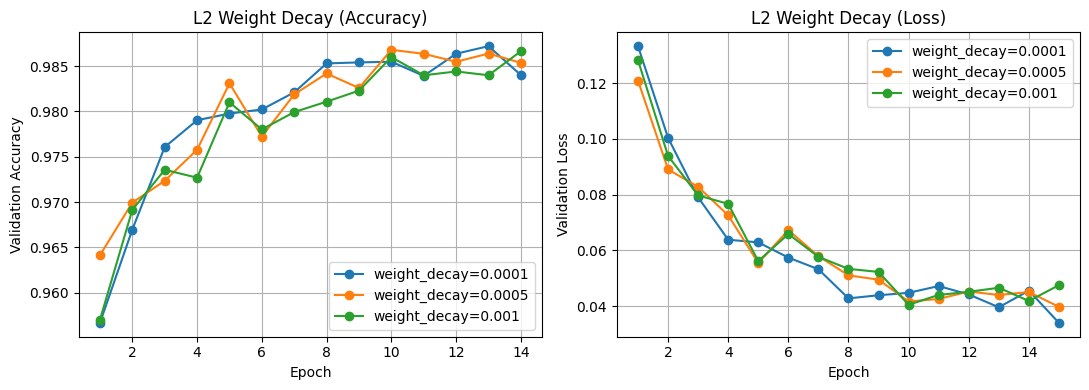

Seed set to 42
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


[selected] weight_decay = 0.0001

*** SWEEP: activation

***[RUN] activation=relu | seed=42
    hparams: activation=relu, depth=3, dropout_p=0.0, lr=0.002, optimizer=adamw, use_bn=True, weight_decay=0.0001, weight_init=he, width=256


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | encoder   | Sequential         | 334 K  | train
1 | head      | Linear             | 2.6 K  | train
2 | criterion | CrossEntropyLoss   | 0      | train
3 | acc_tr    | MulticlassAccuracy | 0      | train
4 | acc_va    | MulticlassAccuracy | 0      | train
5 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
336 K     Trainable params
0         Non-trainable params
336 K     Total params
1.347     Total estimated model params size (MB)
15        Modules in train mode
0         Modules in eval mode


Epoch 14: 100%|██████████| 860/860 [00:05<00:00, 161.27it/s, v_num=19, train_loss_step=0.108, val_loss=0.034, val_acc=0.989, lr=0.002, train_loss_epoch=0.0851, train_acc=0.972]   

`Trainer.fit` stopped: `max_epochs=15` reached.


...

***[RESULT] activation=tanh → best_val_acc=0.9826 (epoch 10), final_val_acc=0.9824 | best_val_loss=0.0547 (epoch 14), final_val_loss=0.0575


***[RUN] activation=sigmoid | seed=42
    hparams: activation=sigmoid, depth=3, dropout_p=0.0, lr=0.002, optimizer=adamw, use_bn=True, weight_decay=0.0001, weight_init=he, width=256


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | encoder   | Sequential         | 334 K  | train
1 | head      | Linear             | 2.6 K  | train
2 | criterion | CrossEntropyLoss   | 0      | train
3 | acc_tr    | MulticlassAccuracy | 0      | train
4 | acc_va    | MulticlassAccuracy | 0      | train
5 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
336 K     Trainable params
0         Non-trainable params
336 K     Total params
1.347     Total estimated model params size (MB)
15        Modules in train

Epoch 14: 100%|██████████| 860/860 [00:06<00:00, 125.80it/s, v_num=24, train_loss_step=0.274, val_loss=0.0611, val_acc=0.978, lr=0.002, train_loss_epoch=0.109, train_acc=0.964]  

`Trainer.fit` stopped: `max_epochs=15` reached.


Epoch 14: 100%|██████████| 860/860 [00:06<00:00, 125.57it/s, v_num=24, train_loss_step=0.274, val_loss=0.0611, val_acc=0.978, lr=0.002, train_loss_epoch=0.109, train_acc=0.964]
***[RESULT] activation=sigmoid → best_val_acc=0.9831 (epoch 11), final_val_acc=0.9826 | best_val_loss=0.0534 (epoch 13), final_val_loss=0.0611

     param     value  best_val_acc  best_epoch  final_val_acc  best_val_loss  best_loss_epoch  final_val_loss
activation      relu      0.987214          13       0.984023       0.033999               15        0.033999
activation      gelu      0.986605          14       0.986605       0.040232               13        0.041772
activation leakyrelu      0.985079          14       0.985079       0.043668               13        0.043892
activation       elu      0.984342          13       0.982181       0.051640               13        0.056445
activation   sigmoid      0.983064          11       0.982561       0.053350               13        0.061124
activation      tan

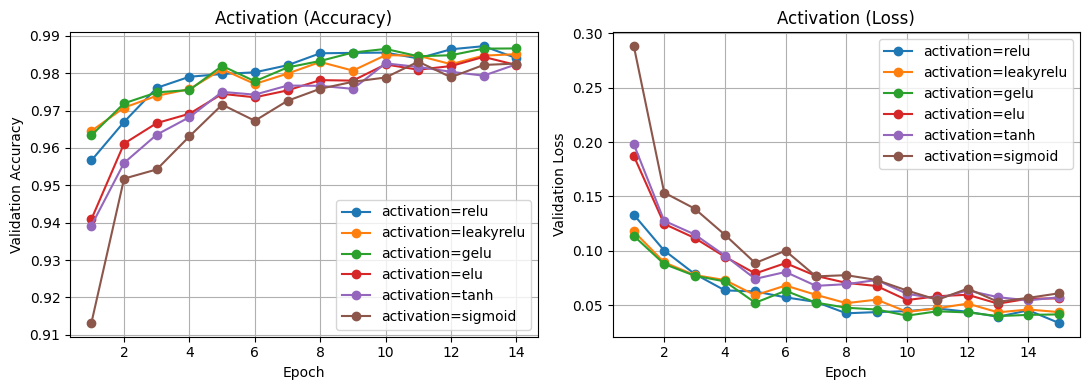

Seed set to 42


[selected] activation = relu

*** SWEEP: weight_init

***[RUN] weight_init=he | seed=42
    hparams: activation=relu, depth=3, dropout_p=0.0, lr=0.002, optimizer=adamw, use_bn=True, weight_decay=0.0001, weight_init=he, width=256


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | encoder   | Sequential         | 334 K  | train
1 | head      | Linear             | 2.6 K  | train
2 | criterion | CrossEntropyLoss   | 0      | train
3 | acc_tr    | MulticlassAccuracy | 0      | train
4 | acc_va    | MulticlassAccuracy | 0      | train
5 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
336 K     Trainable params
0         Non-trainable params
336 K     Total params
1.347     Total estimated model params size (MB)
15        Modules in train

Epoch 14: 100%|██████████| 860/860 [00:05<00:00, 147.18it/s, v_num=6, train_loss_step=0.108, val_loss=0.034, val_acc=0.989, lr=0.002, train_loss_epoch=0.0851, train_acc=0.972]   

`Trainer.fit` stopped: `max_epochs=15` reached.


...

***[RESULT] weight_init=he → best_val_acc=0.9872 (epoch 13), final_val_acc=0.9840 | best_val_loss=0.0340 (epoch 15), final_val_loss=0.0340


***[RUN] weight_init=xavier | seed=42
    hparams: activation=relu, depth=3, dropout_p=0.0, lr=0.002, optimizer=adamw, use_bn=True, weight_decay=0.0001, weight_init=xavier, width=256


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | encoder   | Sequential         | 334 K  | train
1 | head      | Linear             | 2.6 K  | train
2 | criterion | CrossEntropyLoss   | 0      | train
3 | acc_tr    | MulticlassAccuracy | 0      | train
4 | acc_va    | MulticlassAccuracy | 0      | train
5 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
336 K     Trainable params
0         Non-trainable params
336 K     Total params
1.347     Total estimated model params size (MB)
15        Modules in train

Epoch 14: 100%|██████████| 860/860 [00:05<00:00, 156.87it/s, v_num=7, train_loss_step=0.0247, val_loss=0.0479, val_acc=0.985, lr=0.002, train_loss_epoch=0.0868, train_acc=0.971] 

`Trainer.fit` stopped: `max_epochs=15` reached.


Epoch 14: 100%|██████████| 860/860 [00:05<00:00, 156.51it/s, v_num=7, train_loss_step=0.0247, val_loss=0.0479, val_acc=0.985, lr=0.002, train_loss_epoch=0.0868, train_acc=0.971]
***[RESULT] weight_init=xavier → best_val_acc=0.9875 (epoch 13), final_val_acc=0.9872 | best_val_loss=0.0424 (epoch 13), final_val_loss=0.0479

      param  value  best_val_acc  best_epoch  final_val_acc  best_val_loss  best_loss_epoch  final_val_loss
weight_init xavier      0.987481          13       0.987181       0.042446               13        0.047893
weight_init     he      0.987214          13       0.984023       0.033999               15        0.033999


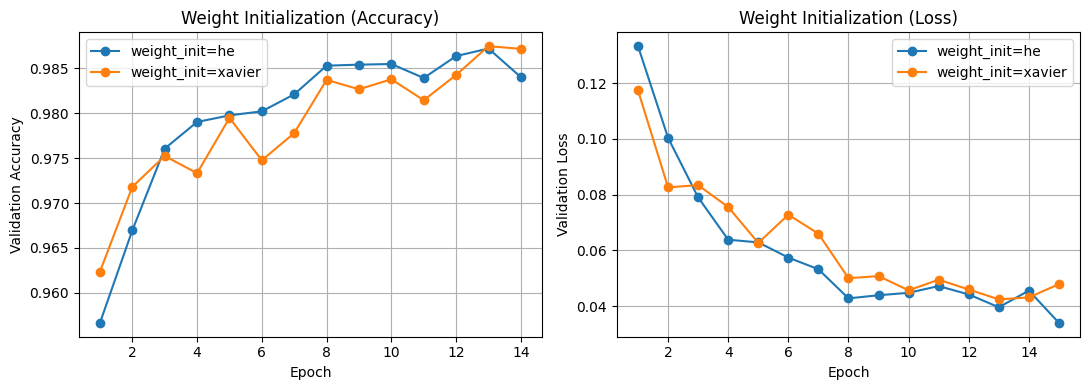

Seed set to 42
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


[selected] weight_init = xavier

*** SWEEP: optimizer

***[RUN] optimizer=adam | seed=42
    hparams: activation=relu, depth=3, dropout_p=0.0, lr=0.002, optimizer=adam, use_bn=True, weight_decay=0.0001, weight_init=xavier, width=256


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | encoder   | Sequential         | 334 K  | train
1 | head      | Linear             | 2.6 K  | train
2 | criterion | CrossEntropyLoss   | 0      | train
3 | acc_tr    | MulticlassAccuracy | 0      | train
4 | acc_va    | MulticlassAccuracy | 0      | train
5 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
336 K     Trainable params
0         Non-trainable params
336 K     Total params
1.347     Total estimated model params size (MB)
15        Modules in train mode
0         Modules in eval mode


Epoch 14: 100%|██████████| 860/860 [00:05<00:00, 163.74it/s, v_num=12, train_loss_step=0.018, val_loss=0.0647, val_acc=0.979, lr=0.002, train_loss_epoch=0.119, train_acc=0.960]  

`Trainer.fit` stopped: `max_epochs=15` reached.


...

***[RESULT] optimizer=sgd → best_val_acc=0.9809 (epoch 13), final_val_acc=0.9798 | best_val_loss=0.0593 (epoch 15), final_val_loss=0.0593


***[RUN] optimizer=rmsprop | seed=42
    hparams: activation=relu, depth=3, dropout_p=0.0, lr=0.002, optimizer=rmsprop, use_bn=True, weight_decay=0.0001, weight_init=xavier, width=256


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | encoder   | Sequential         | 334 K  | train
1 | head      | Linear             | 2.6 K  | train
2 | criterion | CrossEntropyLoss   | 0      | train
3 | acc_tr    | MulticlassAccuracy | 0      | train
4 | acc_va    | MulticlassAccuracy | 0      | train
5 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
336 K     Trainable params
0         Non-trainable params
336 K     Total params
1.347     Total estimated model params size (MB)
15        Modules in train

Epoch 14: 100%|██████████| 860/860 [00:05<00:00, 155.94it/s, v_num=15, train_loss_step=0.417, val_loss=0.176, val_acc=0.945, lr=0.002, train_loss_epoch=0.327, train_acc=0.898] 

`Trainer.fit` stopped: `max_epochs=15` reached.


Epoch 14: 100%|██████████| 860/860 [00:05<00:00, 155.59it/s, v_num=15, train_loss_step=0.417, val_loss=0.176, val_acc=0.945, lr=0.002, train_loss_epoch=0.327, train_acc=0.898]
***[RESULT] optimizer=rmsprop → best_val_acc=0.9517 (epoch 9), final_val_acc=0.9456 | best_val_loss=0.1594 (epoch 9), final_val_loss=0.1765

    param   value  best_val_acc  best_epoch  final_val_acc  best_val_loss  best_loss_epoch  final_val_loss
optimizer   adamw      0.987481          13       0.987181       0.042446               13        0.047893
optimizer    adam      0.983848           8       0.979407       0.051515                9        0.064715
optimizer     sgd      0.980945          13       0.979849       0.059326               15        0.059326
optimizer rmsprop      0.951722           9       0.945579       0.159440                9        0.176488


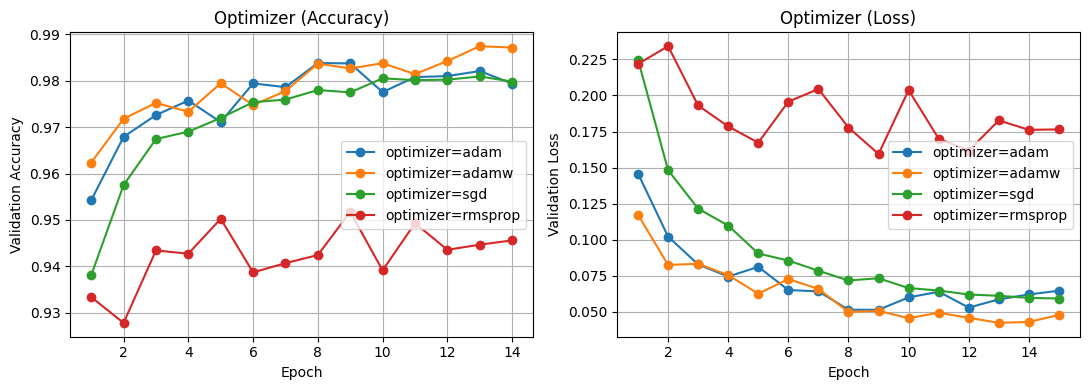

[selected] optimizer = adamw

Best baseline after all sweeps:
 batch_size: 64
 lr: 0.002
 optimizer: adamw
 weight_decay: 0.0001
 activation: relu
 width: 256
 depth: 3
 dropout_p: 0.0
 use_bn: True
 weight_init: xavier


In [7]:
for name, title, values in sweeps:
    
    print(f"\n*** SWEEP: {name}")

    if name == "batch_size":
        bs_eval = BatchSizeEvaluator(
            base=baseline,
            epochs=EPOCHS_SWEEP,
            seed=SEED,
            plot=True,
            dm_kwargs={
                "data_dir": "./datasets",
                "num_workers": 0,
                "val_size": 5000,
                "augment": True,
                "pin_memory": True,
            },
            log_root="logs/mnist_mlp_sweeps",
            name="sweep_batch_size",
        )
        df_bs = bs_eval.run(values, title=title)
        baseline["batch_size"] = cast_like(df_bs.iloc[0]["value"], baseline["batch_size"])
        print(f"[selected] batch_size = {baseline['batch_size']}")
        continue

    dm = MNISTDataModule(
        batch_size=int(baseline["batch_size"]),
        augment=True
    )

    evaluator = HyperParameterEvaluator(
        dm=dm,
        epochs=EPOCHS_SWEEP,
        seed=SEED,
        plot=True,
        base=baseline,
        log_root="logs/mnist_mlp_sweeps",
        model_cls=MNISTMLP,
    )    

    results_table = evaluator.sweep(name, values, title=title)
    chosen = cast_like(results_table.iloc[0]["value"], baseline[name])
    baseline[name] = chosen
    print(f"[selected] {name} = {baseline[name]}")

print("\nBest baseline after all sweeps:")
for k, v in baseline.items():
    print(f" {k}: {v}")

### Final training on the consolidated best configuration

In [8]:
# Since this is our last run, set more epochs and configure early stopping
FINAL_EPOCHS = 50
PATIENCE = 7
EARLY_STOPPING_MIN_DELTA = 1e-4
CHECKPOINT_TOP_K = 1
SCHEDULER="cosine"
LEARNING_RATE_FLOOR = 1e-5
LOG_ROOT = "logs"
EXP_NAME = "mnist_mlp_final"

# Build a fresh DataModule with the chosen batch_size
dm = MNISTDataModule(
    batch_size=int(baseline["batch_size"]),
    augment=True
)

model = MNISTMLP(
	lr=float(baseline["lr"]),
	optimizer=str(baseline["optimizer"]),
	weight_decay=float(baseline["weight_decay"]),
	activation=str(baseline["activation"]),
	width=int(baseline["width"]),
	depth=int(baseline["depth"]),
	dropout_p=float(baseline["dropout_p"]),
	use_bn=bool(baseline["use_bn"]),
	weight_init=str(baseline["weight_init"]),
	scheduler=SCHEDULER,
	t_max=FINAL_EPOCHS,
	eta_min=LEARNING_RATE_FLOOR,
)

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=PATIENCE,
        min_delta=EARLY_STOPPING_MIN_DELTA
    ),
    ModelCheckpoint(
        monitor="val_acc",
        mode="max",
        save_top_k=CHECKPOINT_TOP_K,
        dirpath="checkpoints",
        filename="mnist_mlp_best"
    )
]

csv_logger = CSVLogger(
    save_dir=LOG_ROOT,
    name=EXP_NAME
)

trainer = L.Trainer(
    max_epochs=FINAL_EPOCHS,
    accelerator="auto",
    devices="auto",
    precision="32-true",
    log_every_n_steps=10,
    deterministic=True,
    num_sanity_val_steps=0,
    callbacks=callbacks,
    logger=csv_logger,
)

trainer.fit(model, datamodule=dm)
trainer.test(ckpt_path="best", datamodule=dm)

metrics_csv = f"Logs written to: {csv_logger.log_dir}/metrics.csv"
print("Metrics CSV:", metrics_csv)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/logus/env/iscte/mnist_digits/lib/python3.10/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:751: Checkpoint directory /home/logus/env/iscte/mnist_digits/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | encoder   | Sequential         | 334 K  | train
1 | head      | Linear             | 2.6 K  | train
2 | criterion | CrossEntropyLoss   | 0      | train
3 | acc_tr    | MulticlassAccuracy | 0      | train
4 | acc_va    | MulticlassAccuracy | 0      | train
5 | acc_te    | MulticlassAccuracy | 0      | train
---------------------------------------------------------
336 K     Trainable params
0         Non-trainable params
336 K     Total params
1.347     Total estimated model params size (MB)
15        Modules in 

Epoch 49: 100%|██████████| 860/860 [00:05<00:00, 152.31it/s, v_num=2, train_loss_step=0.0552, val_loss=0.019, val_acc=0.994, lr=1.2e-5, train_loss_epoch=0.0298, train_acc=0.990]     

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 860/860 [00:05<00:00, 152.22it/s, v_num=2, train_loss_step=0.0552, val_loss=0.019, val_acc=0.994, lr=1.2e-5, train_loss_epoch=0.0298, train_acc=0.990]


Restoring states from the checkpoint path at /home/logus/env/iscte/mnist_digits/checkpoints/mnist_mlp_best-v1.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /home/logus/env/iscte/mnist_digits/checkpoints/mnist_mlp_best-v1.ckpt


Testing DataLoader 0: 100%|██████████| 157/157 [00:00<00:00, 288.73it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.9936404228210449
        test_loss          0.019513627514243126
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Metrics CSV: Logs written to: logs/mnist_mlp_final/version_2/metrics.csv
